# Experiment 6: Spam Email Detection

In this experiment, we implement a Spam Filter using a **Naive Bayes Classifier**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

np.random.seed(42)

## 1. Data Loading and Exploration

Dataset Shape: (5569, 2)


,Category,Messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


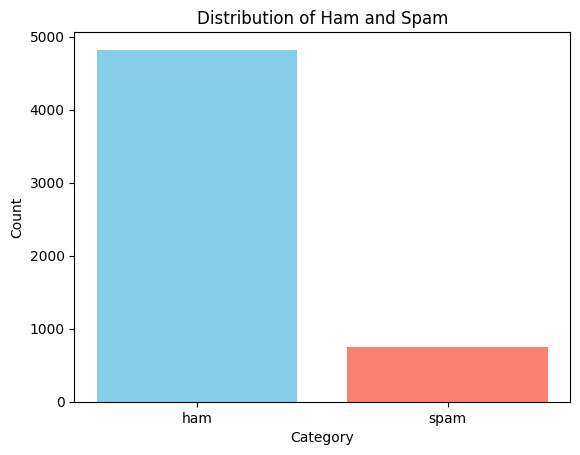

In [2]:
# Load the dataset
df = pd.read_csv('Spam.csv')

# Drop missing values
df = df.dropna()

print(f"Dataset Shape: {df.shape}")
display(df.head())

# Check class distribution
counts = df['Category'].value_counts()
plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])
plt.title('Distribution of Ham and Spam')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

## 2. Preprocessing

In [3]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['Messages'] = df['Messages'].apply(clean_text)
display(df.head())

,Category,Messages
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


## 3. Train-Test Split

We will split the data into 80% training and 20% testing.

In [4]:
# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

Training samples: 4455
Testing samples: 1114


## 4. Naive Bayes Implementation

In [5]:
class NaiveBayes:
    def __init__(self, alpha=1):
        self.alpha = alpha
        self.p_spam = 0
        self.p_ham = 0
        self.spam_word_counts = {}
        self.ham_word_counts = {}
        self.vocab = set()
        self.total_spam_words = 0
        self.total_ham_words = 0

    def fit(self, X, y):
        n = len(y)
        n_spam = sum(y == 'spam')
        n_ham = n - n_spam
        
        # Priors
        self.p_spam = n_spam / n
        self.p_ham = n_ham / n
        
        for text, label in zip(X, y):
            words = str(text).split()
            if label == 'spam':
                for word in words:
                    self.spam_word_counts[word] = self.spam_word_counts.get(word, 0) + 1
                    self.total_spam_words += 1
                    self.vocab.add(word)
            else:
                for word in words:
                    self.ham_word_counts[word] = self.ham_word_counts.get(word, 0) + 1
                    self.total_ham_words += 1
                    self.vocab.add(word)

    def predict(self, X):
        predictions = []
        vocab_size = len(self.vocab)
        
        for text in X:
            words = str(text).split()
            
            # Start with log of priors
            log_p_spam = np.log(self.p_spam)
            log_p_ham = np.log(self.p_ham)
            
            for word in words:
                # P(word | spam)
                p_word_spam = (self.spam_word_counts.get(word, 0) + self.alpha) / \
                              (self.total_spam_words + self.alpha * vocab_size)
                
                # P(word | ham)
                p_word_ham = (self.ham_word_counts.get(word, 0) + self.alpha) / \
                             (self.total_ham_words + self.alpha * vocab_size)
                
                log_p_spam += np.log(p_word_spam)
                log_p_ham += np.log(p_word_ham)
            
            if log_p_spam > log_p_ham:
                predictions.append('spam')
            else:
                predictions.append('ham')
        return np.array(predictions)

## 5. Model Training and Evaluation

Accuracy: 97.40%


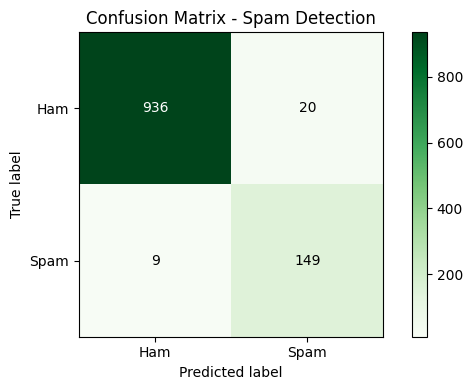


Confusion Matrix Details:
True Positives (Spam): 149
True Negatives (Ham): 936
False Positives: 20
False Negatives: 9

Precision: 0.8817
Recall: 0.9430
F1-Score: 0.9113


In [6]:
# Initialize and train the model
model = NaiveBayes(alpha=1)
model.fit(train_df['Messages'], train_df['Category'])

# Make predictions on the test set
y_pred = model.predict(test_df['Messages'])
y_true = test_df['Category'].values

# Calculate Accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix components
tp = sum((y_pred == 'spam') & (y_true == 'spam'))
tn = sum((y_pred == 'ham') & (y_true == 'ham'))
fp = sum((y_pred == 'spam') & (y_true == 'ham'))
fn = sum((y_pred == 'ham') & (y_true == 'spam'))
conf_matrix = np.array([[tn, fp], [fn, tp]])

# Visualization
plt.figure(figsize=(6, 4))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Greens)
plt.title('Confusion Matrix - Spam Detection')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Ham', 'Spam'])
plt.yticks(tick_marks, ['Ham', 'Spam'])

# Add text annotations
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Details:")
print(f"True Positives (Spam): {tp}")
print(f"True Negatives (Ham): {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Precision, Recall, F1-Score
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

## 6. Testing with custom messages

In [7]:
def predict_message(message):
    cleaned = clean_text(message)
    prediction = model.predict([cleaned])[0]
    return prediction

test_messages = [
    "Congratulations! You've won a $1,000 Walmart gift card. Click here to claim.",
    "Hey, are we still meeting for lunch today?",
    "URGENT: Your bank account has been compromised. Please call 1-800-FAKE-NUM now.",
    "The project report is due tomorrow morning. Please review the draft."
]

for msg in test_messages:
    print(f"Message: {msg}")
    print(f"Prediction: {predict_message(msg)}\n")

Message: Congratulations! You've won a $1,000 Walmart gift card. Click here to claim.
Prediction: spam

Message: Hey, are we still meeting for lunch today?
Prediction: ham

Message: URGENT: Your bank account has been compromised. Please call 1-800-FAKE-NUM now.
Prediction: spam

Message: The project report is due tomorrow morning. Please review the draft.
Prediction: ham

